# Live Demo: Full Pipeline Execution

This notebook runs the complete HiGI IDS pipeline — ingestion, training, detection, and forensic
reporting — on two PCAP files from the **CIC‑IDS2017** dataset. Analysis scoped to victim host **192.168.10.50** (Ubuntu Server). Every cell shows the actual output
you would see in a terminal session.

> ## Performance Disclaimer: Environment Latency

The execution times reported in this notebook can be up to **2× slower** than running the same
commands directly in a terminal (e.g. ~12.9 s vs ~6.9 s for ingestion).

**Why?**

- **I/O Overhead** – Log serialisation through ZMQ sockets for the Jupyter web interface adds latency.
- **Process Management** – The terminal uses a clean `forkserver`; the Jupyter kernel carries
  session metadata into every `Joblib`/`Polars` subprocess.
- **Context Switching** – BLAS thread scheduling is more efficient under the bare Linux scheduler
  than under the notebook server’s abstraction layer.

### 0. Environment Setup
Standard data‑science imports plus `joblib` for model persistence and `IPython.display` to render
the forensic report inline.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys
from IPython.display import clear_output
import joblib
import json
from IPython.display import Markdown, display

### 1. Project Root & Preflight

The notebook automatically locates the project root (where `config.yaml` lives) and adds it to
`sys.path`.  The preflight module (`src.utils.parallelism`) configures BLAS threads, `Joblib`
workers, and `Polars` parallelism to avoid resource contention.

In [2]:

while not os.path.exists('config.yaml'):
    current_dir = os.getcwd()
    os.chdir('..')
    if os.getcwd() == current_dir: 
        break
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

clear_output()

print(f" HiGI Environment Initialized")
print(f" Project Root: [{os.path.basename(os.getcwd())}]")
print(f" Python Path: OK")

 HiGI Environment Initialized
 Project Root: [HiGI]
 Python Path: OK


## 1. Baseline Training

We train the model on **Monday’s benign traffic** (`Hybrid_Baseline.pcap`) so it can learn
what “normal” looks like for this network.

**What happens during training:**
1. **Ingestion** – the PCAP is streamed in chunks, parsed, and sorted chronologically.
2. **Feature extraction** – 36 physical features are aggregated into 1‑second windows.
3. **Hilbert projection** – Blocked PCA across five physical families compresses the data to
   23 dimensions while preserving interpretability.
4. **Detector fitting** – the BallTree, Bayesian GMM (15 components), Isolation Forest, and
   per‑feature univariate GMMs are all fitted on the baseline distribution.
5. **Bundle creation** – the trained engine, scaler, and metadata are serialised into a single
   `.pkl` file.

The whole process takes ~4 minutes on a modern laptop.

In [3]:
!time python3 main.py train --source data/raw/CIC-IDS2017/Hybrid_Baseline.pcap --bundle models/hybrid_baseline.pkl 

[PREFLIGHT] Thread limits set:
  Parent BLAS threads: 1
  Joblib workers: 6
  Joblib start method: forkserver (prevents virtual memory bloat)
  Polars parallelism: 6
[2026-04-30 13:51:36] [INFO    ] [higi] HiGI IDS v4.0  |  mode=train
[2026-04-30 13:51:36] [INFO    ] [higi.train] ================================================================================
[2026-04-30 13:51:36] [INFO    ] [higi.train] HiGI TRAINING MODE
[2026-04-30 13:51:36] [INFO    ] [higi.train] ================================================================================
[2026-04-30 13:51:36] [INFO    ] [higi.train]   Source PCAP : data/raw/CIC-IDS2017/Hybrid_Baseline.pcap
[2026-04-30 13:51:36] [INFO    ] [higi.train]   Output Bundle: models/hybrid_baseline.pkl
[2026-04-30 13:51:36] [INFO    ] [higi.train] 
[2026-04-30 13:51:36] [INFO    ] [higi.train] Injected Configuration:
[2026-04-30 13:51:36] [INFO    ] [higi.train]   Engine config: higi_config.use_bayesian_gmm=True, higi_config.gmm_score_normalization_m

### 1.1 Trained Model Verification

A quick sanity check: we load the bundle and confirm it contains both the `RobustScaler` and the
`HiGIEngine` with all expected components.

In [4]:
output_path = 'models/hybrid_baseline.pkl'
if os.path.exists(output_path):
    print(f" Model saved successfully at: {output_path}")
else:
    print(f" Model not found at: {output_path}")
bundle = joblib.load(output_path)
print("✅ Model loaded successfully, ready for inference!")
print(f"Contiene Scaler: {'✓' if 'scaler' in bundle else '✗'}")
print(f"Contiene Engine: {'✓' if 'engine' in bundle else '✗'}")
print(f"Engine attributes: {list(bundle['engine'].__dict__.keys())[:5]}...")

 Model saved successfully at: models/hybrid_baseline.pkl


✅ Model loaded successfully, ready for inference!
Contiene Scaler: ✓
Contiene Engine: ✓
Engine attributes: ['config', 'n_jobs', 'projector', 'balltree_detector', 'gmm_detector']...


### 1.2 Baseline Data Preview

Let’s look at a few rows of the aggregated feature matrix produced from the Monday PCAP.

- **Left plot** – PPS velocity (first derivative of packet rate). In benign traffic it clusters
  tightly around zero, with occasional bursts.
- **Right plot** – Distribution of protocol/flag ratios. They hover near their long‑run
  proportions; sharp deviations here are exactly what the Physical Sentinel watches for.

 Dataset found at: data/processed/audit_Hybrid_Baseline.csv
Dataset: 5670 ventanas | 39 descriptores


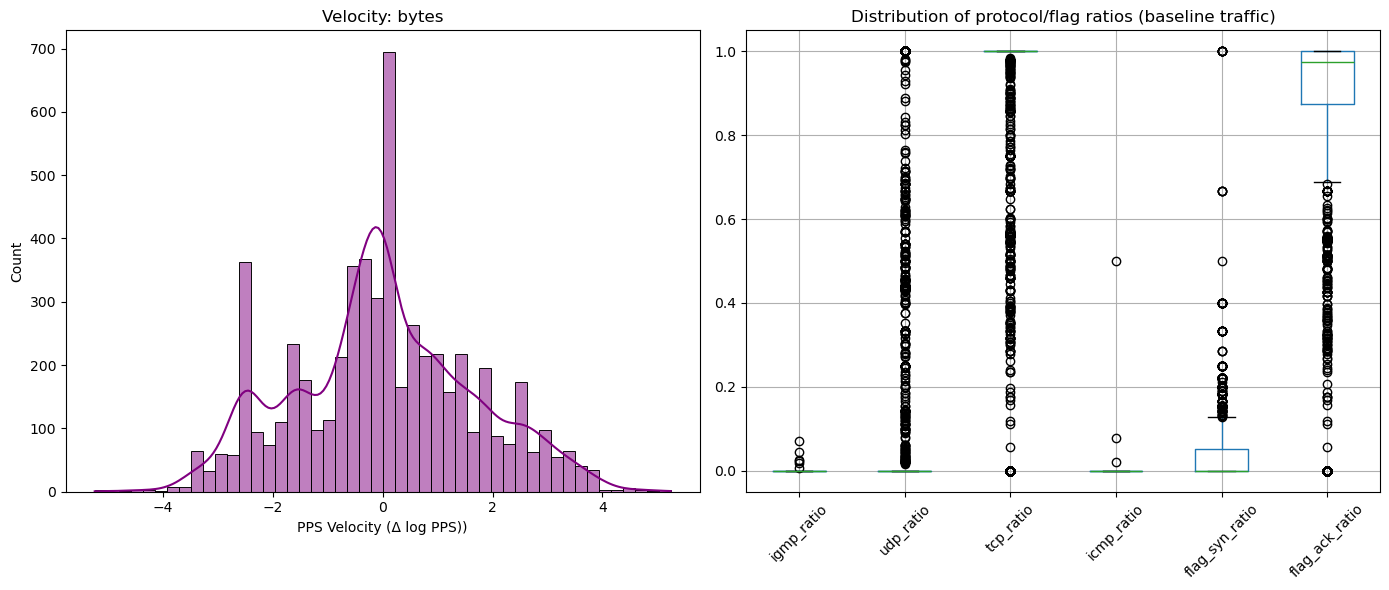

,dt,bytes,unique_dst_ports,size_avg,entropy_avg,size_max,total_pps_log,total_bytes_log,igmp_ratio,udp_ratio,tcp_ratio,icmp_ratio,flag_syn_ratio,flag_ack_ratio,flag_fin_ratio,flag_rst_ratio,flag_psh_ratio,flag_urg_ratio,port_scan_ratio,burst_factor,flow_duration,payload_continuity,payload_continuity_ratio,server_port,iat_mean,pps_velocity,bytes_velocity,entropy_velocity,pps_acceleration,bytes_acceleration,entropy_acceleration,pps_volatility,bytes_volatility,entropy_volatility,pps_momentum,vel_pps_z,vel_bytes_z,vel_syn_z,_abs_timestamp
0,1499083068,2568,2,111.652174,3.827344,141,3.178054,7.851272,0.043478,0.956522,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.086957,1.262850,0.165282,69.565217,0.000000,5353,0.007513,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0,0.0,0.0,0.0,1.499083e+09
1,1499083069,5538,2,123.066667,4.151256,141,3.828641,8.619569,0.022222,0.977778,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.044444,1.145720,0.674902,81.022222,0.000000,5353,0.015339,0.650588,0.768297,0.323912,0.650588,0.768297,0.323912,0.000000,0.00000,0.000000,0,0.0,0.0,0.0,1.499083e+09
2,1499083070,12600,10,134.042553,3.968868,199,4.553877,9.441531,0.000000,0.978723,0.000000,0.021277,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.106383,1.484603,0.502111,92.212766,0.138874,5353,0.005399,0.725235,0.821962,-0.182387,0.074648,0.053665,-0.506299,0.000000,0.00000,0.000000,0,0.0,0.0,0.0,1.499083e+09
3,1499083071,101076,80,209.701245,3.853879,3135,6.180017,11.523638,0.000000,0.618257,0.381743,0.000000,0.049793,0.356846,0.016598,0.016598,0.190871,0.0,0.165975,14.949840,0.902152,158.307054,0.224305,56772,0.001876,1.626140,2.082106,-0.114989,0.900904,1.260144,0.067398,0.000000,0.00000,0.000000,0,0.0,0.0,0.0,1.499083e+09
4,1499083072,3900,3,150.000000,4.106718,187,3.295837,8.268988,0.000000,0.923077,0.000000,0.076923,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.115385,1.246667,0.518342,108.615385,0.000000,5353,0.020734,-2.884180,-3.254650,0.252838,-4.510320,-5.336756,0.367828,1.229352,1.45456,0.145522,0,0.0,0.0,0.0,1.499083e+09


In [5]:
output_path = 'data/processed/audit_Hybrid_Baseline.csv'
if os.path.exists(output_path):
    print(f" Dataset found at: {output_path}")
else:    print(f"  Dataset not found at: {output_path}")   
df = pd.read_csv(output_path)
pd.set_option('display.max_columns', None)

ratios = [col for col in df.columns if 'ratio' in col]
intensity_cols = [col for col in df.columns if 'total' in col or 'bytes' in col]

print(f"Dataset: {df.shape[0]} ventanas | {df.shape[1]} descriptores")

# Visualización Dual
plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)
sns.histplot(df['pps_velocity'], kde=True, color='purple')
plt.title(f"Velocity: {intensity_cols[0]}")
plt.xlabel("PPS Velocity (Δ log PPS))")

plt.subplot(1, 2, 2)
df[ratios[:6]].boxplot() 
plt.title("Distribution of protocol/flag ratios (baseline traffic)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


display(df.head())

## 2. Detection on Wednesday’s Attack Traffic

We now feed the **Wednesday PCAP** — which contains four different DoS/DDoS campaigns — to the
trained engine.  The engine has never seen attack traffic before.

**What the logs show:**
- **Ingestion** – 2.6 M packets processed in ~169 s.
- **Tier 1 (BallTree)** – 3 160 windows are trivially normal; 3 486 proceed to deeper inspection.
- **Tier 4 (Velocity Bypass)** – 32 windows trigger the emergency gate (rapid‑onset floods).
- **Tiers 2 & 3** – the remaining detectors vote on each suspect window.
- **Persistence & hysteresis** filters suppress 162 transient windows, leaving 3 461 confirmed
  anomalies.

**Key takeaway:** pure inference (excluding file I/O) completes in **6.1 seconds** — about
1 090 windows per second.

In [6]:
!time python3 main.py detect --source data/raw/CIC-IDS2017/Wednesday_Victim_50.pcap --bundle models/hybrid_baseline.pkl 


[PREFLIGHT] Thread limits set:
  Parent BLAS threads: 1
  Joblib workers: 6
  Joblib start method: forkserver (prevents virtual memory bloat)
  Polars parallelism: 6
[2026-04-30 13:54:38] [INFO    ] [higi] HiGI IDS v4.0  |  mode=detect
[2026-04-30 13:54:38] [INFO    ] [higi.detect] ================================================================================
[2026-04-30 13:54:38] [INFO    ] [higi.detect] HiGI DETECTION MODE
[2026-04-30 13:54:38] [INFO    ] [higi.detect] ================================================================================
[2026-04-30 13:54:38] [INFO    ] [higi.detect]   Source PCAP  : data/raw/CIC-IDS2017/Wednesday_Victim_50.pcap
[2026-04-30 13:54:38] [INFO    ] [higi.detect]   Bundle       : models/hybrid_baseline.pkl
[2026-04-30 13:54:38] [INFO    ] [higi.detect]   Output CSV   : data/processed/Wednesday_Victim_50_results.csv
[2026-04-30 13:54:38] [INFO    ] [higi.detect] 
[2026-04-30 13:54:38] [INFO    ] 
[2026-04-30 13:54:38] [INFO    ] [HiGI_Orchestr

### 2.1 Anomaly Results — Top Culprits

Each anomalous window receives a **physical culprit label** — the feature that deviated most
from the baseline, with its direction (SPIKE / DROP) and σ magnitude.

The top culprits already hint at the attack types:
- `flag_syn_ratio` (SYN flood / port scan)
- `payload_continuity_ratio` (application‑layer flood)

In [7]:
output_path = 'data/processed/Wednesday_Victim_50_results.csv'
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
if os.path.exists(output_path):
    print(f" Dataset found at: {output_path}")
else:    
    print(f" Dataset not found at: {output_path}")
    exit(1)
df_results = pd.read_csv(output_path)

display(df_results.head())

print("\n TOP PHYSICAL CULPRITS")
print(df_results[df_results['is_anomaly'] == 1][['physical_culprit', 'family_consensus']].value_counts().head(5))

 Dataset found at: data/processed/Wednesday_Victim_50_results.csv


,Unnamed: 0,balltree_score,balltree_severity,gmm_score,gmm_anomaly,iforest_score,iforest_anomaly,consensus_votes,is_anomaly,severity,persistence,anomaly_ma_score,physical_culprit,culprit_component,culprit_deviation,forensic_evidence,is_warmup,family_consensus,vel_score,vel_bypass,vel_culprit,server_port,_abs_timestamp,soft_zone_triggered
0,0,0.472417,0.0,0.000000,0,0.000000,0,0,0,0.0,NaN,0.472417,NaN,NaN,0.000000,NaN,True,NaN,0.074482,False,NaN,137,1.499255e+09,False
1,1,0.980758,1.0,1.000000,0,0.316959,0,0,0,0.0,Sustained Attack,0.726587,"bytes_volatility (DROP (3626.8%), σ=3.30)",PC2,-4.570275,[BORDERLINE [WARMUP]] Physical: bytes_volatili...,True,kinematics,0.074482,False,NaN,59115,1.499255e+09,False
2,2,0.906827,1.0,1.000000,0,0.394790,1,1,0,0.0,Sustained Attack,0.786667,"bytes_volatility (DROP (3626.8%), σ=3.30) | GM...",PC3,-3.534445,[BORDERLINE [WARMUP]] Physical: bytes_volatili...,True,kinematics,0.074482,False,NaN,59133,1.499255e+09,False
3,3,0.825513,1.0,0.999999,0,0.369518,1,1,1,1.0,Sustained Attack,0.796379,"bytes_volatility (DROP (3626.8%), σ=3.30)",PC1,-3.843783,[BORDERLINE [WARMUP]] Physical: bytes_volatili...,True,kinematics,0.074482,False,NaN,123,1.499255e+09,False
4,4,0.533038,0.0,0.000000,0,0.000000,0,0,1,1.0,Sustained Attack,0.743711,"pps_acceleration (SPIKE (+60476.2%), σ=2.57)",PC1,4.396194,[NORMAL [WARMUP]] Physical: pps_acceleration (...,True,NaN,0.074482,False,NaN,54594,1.499255e+09,False



 TOP PHYSICAL CULPRITS


physical_culprit                                                               family_consensus
flag_syn_ratio (SPIKE (+591.7%), σ=3.10) | GMM: flag_rst_ratio (LL=-6.021)     kinematics          5
flag_syn_ratio (SPIKE (+611.5%), σ=3.20) | GMM: flag_rst_ratio (LL=-5.910)     kinematics          4
flag_syn_ratio (SPIKE (+654.6%), σ=3.42) | GMM: flag_rst_ratio (LL=-6.011)     kinematics          2
flag_syn_ratio (SPIKE (+1283.4%), σ=6.71) | GMM: port_scan_ratio (LL=-9.714)   volume_flood        2
flag_syn_ratio (SPIKE (+1283.4%), σ=6.71) | GMM: port_scan_ratio (LL=-13.424)  volume_flood        2
Name: count, dtype: int64


### 2.2 Detection Summary

The JSON sidecar file records aggregate statistics: total windows, anomaly rate, severity
distribution, directionality (3 582 SPIKEs vs 118 DROPs), and throughput.

In [8]:
open_path = 'data/processed/Wednesday_Victim_50_results.json'
if os.path.exists(open_path):
    print(f"Summary found at: {open_path}")
else:    
    print(f"Summary not found at: {open_path}")
    exit(1)
with open(open_path, 'r') as f:
    summary = json.load(f)
print("📝 DETECTION SUMMARY: Wednesday_Victim_50")
print("===========================================")
print(f"Total Windows:         {summary['total_samples']}")
print(f"Anomalies Detected:    {summary['anomalies_detected']} ({summary['anomaly_rate_pct']:.2f}%)")
print(f"Critical Alerts:       {summary['critical_count']}")
print(f"Soft Zone (Defended):  {summary['soft_zone_count']}")
print(f"Inference Throughput:  {summary['throughput_samples_per_sec']:.2f} samples/sec")
print(f"Inference Duration(Incl. Preprocessing):    {summary['inference_duration_sec']:.2f} s")

Summary found at: data/processed/Wednesday_Victim_50_results.json
📝 DETECTION SUMMARY: Wednesday_Victim_50
Total Windows:         6646
Anomalies Detected:    3461 (52.08%)
Critical Alerts:       551
Soft Zone (Defended):  241
Inference Throughput:  2461.90 samples/sec
Inference Duration(Incl. Preprocessing):    85.95 s


## 3. Forensic Report Generation

The `report` command reads the detection results, clusters consecutive anomalies into incidents
(30 s debounce), computes Dynamic Severity Scores and Consensus Confidence, and produces:

- A **Markdown report** (rendered below)
- A **PDF** for SOC documentation
- **Timeline** and **Radar** charts

**Note on the output:** the engine processes the Wednesday CSV and correctly identifies the four
DoS campaigns (Slowloris, Slowhttptest, Hulk, GoldenEye) as well as pre‑attack reconnaissance.

In [9]:
!time python3 main.py report --results data/processed/Wednesday_Victim_50_results.csv --bundle models/hybrid_baseline.pkl --output reports/forensic_wednesday


[PREFLIGHT] Thread limits set:
  Parent BLAS threads: 1
  Joblib workers: 6
  Joblib start method: forkserver (prevents virtual memory bloat)
  Polars parallelism: 6
[2026-04-30 13:56:10] [INFO    ] [higi] HiGI IDS v4.0  |  mode=report
[2026-04-30 13:56:12] [INFO    ] [✓] Bundle loaded: models/hybrid_baseline.pkl
[2026-04-30 13:56:12] [INFO    ] [HiGI_Orchestrator] [✓] Bundle loaded: models/hybrid_baseline.pkl
[2026-04-30 13:56:12] [INFO    ]     Baseline PCAP: data/raw/CIC-IDS2017/Hybrid_Baseline.pcap
[2026-04-30 13:56:12] [INFO    ] [HiGI_Orchestrator]     Baseline PCAP: data/raw/CIC-IDS2017/Hybrid_Baseline.pcap
[2026-04-30 13:56:12] [INFO    ]     Training date: 2026-04-30T13:54:30.624852
[2026-04-30 13:56:12] [INFO    ] [HiGI_Orchestrator]     Training date: 2026-04-30T13:54:30.624852
[2026-04-30 13:56:12] [INFO    ]     Features: 36
[2026-04-30 13:56:12] [INFO    ] [HiGI_Orchestrator]     Features: 36
[2026-04-30 13:56:12] [INFO    ]     ✓ RobustScaler restored (physics layer)
[20

### 4.1 Forensic Report (Inline)

Below is the **unedited** Markdown report generated by `ForensicEngine V2.0`.  It includes:

- Executive summary
- Physical family stress distribution
- Per‑incident Tier evidence, XAI attribution, and MITRE ATT&CK mapping
- Telemetry data‑drop log

# HiGI IDS — Forensic Security Incident Report

> **Generated:** 2026-04-30 11:56:15 UTC  
> **Source file:** `Wednesday_Victim_50_results.csv`  
> **Analysis window:** 2017-07-05 11:42:42 → 2017-07-05 20:08:17

## Analysis Parameters

| Parameter | Value | Purpose |
|-----------|-------|---------|
| Incident debounce | 30 s | Maximum gap for grouping consecutive anomalies |
| Data-drop threshold | 60 s | Gap size flagged as sensor blindness |
| Confidence filter | 80% | Minimum tier-weighted confidence for reporting |
| Min anomalies/incident | 1 | Alert-fatigue suppression floor |
| Min duration | 1.0 s | Minimum incident duration |
| Min σ culprit | 2.0 | Minimum mean \|σ\| to include in report |

## Executive Summary

- **Total anomalous windows detected:** 3,597
- **Reportable incidents after filtering:** 8
- **Maximum severity:** 3/3 (Critical — Full unanimity)
- **Average severity:** 1.82/3
- **Average incident duration:** 597.7 s
- **Telemetry data-drops detected:** 19

## Physical Family Stress Distribution

| Family | Anomaly Count | Share | Interpretation |
|--------|--------------|-------|----------------|
| **Flags** | 1,245 | 34.6% | TCP-flag manipulation — possible SYN/RST/FIN flood or stealth scan |
| **Connection** | 1,056 | 29.4% | Connection-topology anomaly — port-scan, service discovery |
| **Volume** | 773 | 21.5% | Bandwidth/PPS overload — volumetric DoS or data exfiltration |
| **Payload** | 319 | 8.9% | Payload anomaly — obfuscation, encryption or protocol tunnelling |
| **Kinematics** | 118 | 3.3% | Rate/volatility anomaly — beaconing, slow-rate attack or burst |
| **Volume_flood** | 44 | 1.2% | – |
| **Slow_attack** | 26 | 0.7% | – |
| **Protocol** | 16 | 0.4% | Protocol-ratio shift — possible protocol abuse or evasion |

## Visual Evidence

### Figure 1 — Attack Intensity Timeline

![Attack Intensity Timeline](reports/forensic_wednesday/Wednesday_Victim_50_results_timeline.png)

**Reading guide:** Coloured fill indicates severity level (yellow = Severity 1, orange = Severity 2, red = Severity 3). Teal downward triangles mark Velocity Bypass events. Callout boxes annotate the three highest-severity incidents with their primary culprit metric.

### Figure 2 — Physical Family Stress Radar

![Physical Family Stress Radar](reports/forensic_wednesday/Wednesday_Victim_50_results_radar.png)

**Reading guide:** Each axis represents a physical feature family. A larger filled area indicates that family contributed more anomaly load. Dominant axes identify the primary attack vector and guide immediate countermeasure prioritisation.

## Detailed Incident Analysis

### Incident #20

| Field | Value |
|-------|-------|
| **Start (UTC)** | 2017-07-05 12:26:02 |
| **End (UTC)** | 2017-07-05 12:33:15 |
| **Duration** | 434 s |
| **Anomalous windows** | 79 |
| **Max severity** | 3/3 — Critical — Full unanimity |
| **Dynamic severity score** | 11.57 |
| **Consensus confidence** | 86.6% |
| **Persistence label** | Sustained Attack |
| **Top-3 destination ports** | 443, 54646, 22 |
| **Warm-up period** | No |

#### Tier Evidence

| Tier | Fired | Fire Count | Mean Score |
|------|-------|-----------|------------|
| BallTree | ✅ | 57 | 1.0204 |
| GMM | ✅ | 25 | 0.7215 |
| IForest | ✅ | 26 | 0.2396 |
| PhysicalSentinel | ✅ | 79 | 4.5440 |
| VelocityBypass | — | 0 | 0.1747 |

#### Top-3 Physical Feature Attributions (XAI)

| Rank | Feature | Family | Event Type | Max \|σ\| | Max Δ% | Loading |
|------|---------|--------|-----------|--------|--------|---------|
| 1 | `iat_mean` | Connection | ⬆ SPIKE | 14.60σ | 5099% | 1.000 |
| 2 | `unique_dst_ports` | Connection | ⬆ SPIKE | 8.22σ | 4964% | 0.563 |
| 3 | `flag_rst_ratio` | Kinematics | ⬆ SPIKE | 6.48σ | 6021% | 0.444 |

#### MITRE ATT&CK Mapping

- **Reconnaissance**
  - T1046 – Network Service Discovery
  - T1595.001 – Active Scanning: IP Addresses
  - T1595 – Active Scanning (Stealth FIN Scan)
- **Command & Control**
  - T1573 – Encrypted / Obfuscated Traffic
  - T1071 – Beaconing / Irregular IAT
- **Impact**
  - T1190 – Exploit Public-Facing Application (Slow DoS)
  - T1498.001 – UDP Flood / Amplification
  - T1498 – Volumetric PPS Volatility
  - T1498 – Resource Exhaustion: Bandwidth Volatility
  - T1499.002 – DoS: Endpoint Service (RST Flood)
- **Exfiltration**
  - T1048 – Oversized Packet Exfiltration

### Incident #27

| Field | Value |
|-------|-------|
| **Start (UTC)** | 2017-07-05 12:48:46 |
| **End (UTC)** | 2017-07-05 13:11:30 |
| **Duration** | 1365 s |
| **Anomalous windows** | 1320 |
| **Max severity** | 3/3 — Critical — Full unanimity |
| **Dynamic severity score** | 139.37 |
| **Consensus confidence** | 100.0% |
| **Persistence label** | Sustained Attack |
| **Top-3 destination ports** | 80, 54710, 54722 |
| **Warm-up period** | No |

#### Tier Evidence

| Tier | Fired | Fire Count | Mean Score |
|------|-------|-----------|------------|
| BallTree | ✅ | 1307 | 1.3304 |
| GMM | ✅ | 164 | 0.9902 |
| IForest | ✅ | 864 | 0.3750 |
| PhysicalSentinel | ✅ | 1320 | 3.4856 |
| VelocityBypass | ✅ | 3 | 0.2091 |

#### Top-3 Physical Feature Attributions (XAI)

| Rank | Feature | Family | Event Type | Max \|σ\| | Max Δ% | Loading |
|------|---------|--------|-----------|--------|--------|---------|
| 1 | `unique_dst_ports` | Connection | ⬆ SPIKE | 45.84σ | 27672% | 1.000 |
| 2 | `flag_syn_ratio` | Flags | ⬆ SPIKE | 9.88σ | 1889% | 0.216 |
| 3 | `flag_rst_ratio` | Flags | ⬆ SPIKE | 9.77σ | 9081% | 0.213 |

#### MITRE ATT&CK Mapping

- **Reconnaissance**
  - T1046 – Network Service Discovery
  - T1595.001 – Active Scanning: IP Addresses
  - T1595 – Active Scanning (Stealth FIN Scan)
- **Impact**
  - T1499.002 – DoS: Endpoint Service (RST Flood)
  - T1498 – Volumetric PPS Volatility
  - T1190 – Exploit Public-Facing Application (Slow DoS)
  - T1498.001 – DoS: Direct Network Flood (SYN Flood)
  - T1498 – Resource Exhaustion: Bandwidth Volatility
- **Command & Control**
  - T1071 – Beaconing / Irregular IAT
  - T1573 – Encrypted / Obfuscated Traffic
- **Exfiltration**
  - T1048 – Oversized Packet Exfiltration

### Incident #29

| Field | Value |
|-------|-------|
| **Start (UTC)** | 2017-07-05 13:15:37 |
| **End (UTC)** | 2017-07-05 13:30:54 |
| **Duration** | 917 s |
| **Anomalous windows** | 731 |
| **Max severity** | 3/3 — Critical — Full unanimity |
| **Dynamic severity score** | 748.84 |
| **Consensus confidence** | 100.0% |
| **Persistence label** | Sustained Attack |
| **Top-3 destination ports** | 80, 56326, 54722 |
| **Warm-up period** | No |

#### Tier Evidence

| Tier | Fired | Fire Count | Mean Score |
|------|-------|-----------|------------|
| BallTree | ✅ | 688 | 1.8557 |
| GMM | ✅ | 493 | 0.9412 |
| IForest | ✅ | 541 | 0.4412 |
| PhysicalSentinel | ✅ | 731 | 7.0134 |
| VelocityBypass | ✅ | 8 | 0.2213 |

#### Top-3 Physical Feature Attributions (XAI)

| Rank | Feature | Family | Event Type | Max \|σ\| | Max Δ% | Loading |
|------|---------|--------|-----------|--------|--------|---------|
| 1 | `icmp_ratio` | Protocol | ⬆ SPIKE | 102.80σ | 611480% | 1.000 |
| 2 | `iat_mean` | Connection | ⬆ SPIKE | 45.69σ | 15960% | 0.444 |
| 3 | `bytes` | Volume | ⬆ SPIKE | 43.86σ | 10095% | 0.427 |

#### MITRE ATT&CK Mapping

- **Reconnaissance**
  - T1046 – Network Service Discovery
  - T1595.001 – Active Scanning: IP Addresses
  - T1595 – Active Scanning (Stealth FIN Scan)
- **Impact**
  - T1498.001 – DoS: Direct Network Flood (SYN Flood)
  - T1190 – Exploit Public-Facing Application (Slow DoS)
  - T1498 – Resource Exhaustion: Bandwidth Volatility
  - T1499.002 – DoS: Endpoint Service (RST Flood)
  - T1498 – Volumetric PPS Volatility
- **Command & Control**
  - T1071 – Beaconing / Irregular IAT
  - T1573 – Encrypted / Obfuscated Traffic
- **Exfiltration**
  - T1048 – Oversized Packet Exfiltration

### Incident #30

| Field | Value |
|-------|-------|
| **Start (UTC)** | 2017-07-05 13:32:19 |
| **End (UTC)** | 2017-07-05 13:36:17 |
| **Duration** | 238 s |
| **Anomalous windows** | 143 |
| **Max severity** | 3/3 — Critical — Full unanimity |
| **Dynamic severity score** | 162571.69 |
| **Consensus confidence** | 89.9% |
| **Persistence label** | Sustained Attack |
| **Top-3 destination ports** | 80, 56326, 59500 |
| **Warm-up period** | No |

#### Tier Evidence

| Tier | Fired | Fire Count | Mean Score |
|------|-------|-----------|------------|
| BallTree | ✅ | 132 | 5.3949 |
| GMM | ✅ | 98 | 0.9231 |
| IForest | ✅ | 110 | 0.4645 |
| PhysicalSentinel | ✅ | 143 | 19.7243 |
| VelocityBypass | — | 0 | 0.1876 |

#### Top-3 Physical Feature Attributions (XAI)

| Rank | Feature | Family | Event Type | Max \|σ\| | Max Δ% | Loading |
|------|---------|--------|-----------|--------|--------|---------|
| 1 | `payload_continuity_ratio` | Payload | ⬆ SPIKE | 1917.68σ | 11325711% | 1.000 |
| 2 | `iat_mean` | Connection | ⬆ SPIKE | 26.48σ | 9251% | 0.014 |
| 3 | `bytes` | Volume | ⬆ SPIKE | 25.44σ | 5855% | 0.013 |

#### MITRE ATT&CK Mapping

- **Reconnaissance**
  - T1595.001 – Active Scanning: IP Addresses
  - T1595 – Active Scanning (Stealth FIN Scan)
  - T1046 – Network Service Discovery
- **Command & Control**
  - T1071 – Beaconing / Irregular IAT
  - T1573 – Encrypted / Obfuscated Traffic
- **Impact**
  - T1498.001 – UDP Flood / Amplification
  - T1498 – Volumetric PPS Volatility
  - T1498 – Resource Exhaustion: Bandwidth Volatility
  - T1498.001 – DoS: Direct Network Flood (SYN Flood)
  - T1190 – Exploit Public-Facing Application (Slow DoS)
  - T1499.002 – DoS: Endpoint Service (RST Flood)
- **Exfiltration**
  - T1048 – Oversized Packet Exfiltration

### Incident #34

| Field | Value |
|-------|-------|
| **Start (UTC)** | 2017-07-05 13:43:23 |
| **End (UTC)** | 2017-07-05 14:02:39 |
| **Duration** | 1157 s |
| **Anomalous windows** | 625 |
| **Max severity** | 3/3 — Critical — Full unanimity |
| **Dynamic severity score** | 38410.30 |
| **Consensus confidence** | 100.0% |
| **Persistence label** | Sustained Attack |
| **Top-3 destination ports** | 80, 60092, 59500 |
| **Warm-up period** | No |

#### Tier Evidence

| Tier | Fired | Fire Count | Mean Score |
|------|-------|-----------|------------|
| BallTree | ✅ | 576 | 61.5207 |
| GMM | ✅ | 482 | 0.9216 |
| IForest | ✅ | 502 | 0.6558 |
| PhysicalSentinel | ✅ | 625 | 212.3383 |
| VelocityBypass | ✅ | 2 | 0.1958 |

#### Top-3 Physical Feature Attributions (XAI)

| Rank | Feature | Family | Event Type | Max \|σ\| | Max Δ% | Loading |
|------|---------|--------|-----------|--------|--------|---------|
| 1 | `bytes` | Volume | ⬆ SPIKE | 857.25σ | 197334% | 1.000 |
| 2 | `payload_continuity_ratio` | Payload | ⬆ SPIKE | 46.05σ | 271980% | 0.054 |
| 3 | `iat_mean` | Connection | ⬆ SPIKE | 27.57σ | 9630% | 0.032 |

#### MITRE ATT&CK Mapping

- **Command & Control**
  - T1573 – Encrypted / Obfuscated Traffic
  - T1071 – Beaconing / Irregular IAT
- **Impact**
  - T1498 – Volumetric PPS Volatility
  - T1498 – Resource Exhaustion: Bandwidth Volatility
  - T1498.001 – UDP Flood / Amplification
  - T1499.002 – DoS: Endpoint Service (RST Flood)
  - T1190 – Exploit Public-Facing Application (Slow DoS)
  - T1498.001 – DoS: Direct Network Flood (SYN Flood)
- **Reconnaissance**
  - T1595.001 – Active Scanning: IP Addresses
  - T1595 – Active Scanning (Stealth FIN Scan)
  - T1046 – Network Service Discovery
- **Exfiltration**
  - T1048 – Oversized Packet Exfiltration

### Incident #36

| Field | Value |
|-------|-------|
| **Start (UTC)** | 2017-07-05 14:06:10 |
| **End (UTC)** | 2017-07-05 14:07:38 |
| **Duration** | 88 s |
| **Anomalous windows** | 27 |
| **Max severity** | 2/3 — High — Majority consensus |
| **Dynamic severity score** | 1.60 |
| **Consensus confidence** | 80.6% |
| **Persistence label** | Sustained Attack |
| **Top-3 destination ports** | 80, 60554, 138 |
| **Warm-up period** | No |

#### Tier Evidence

| Tier | Fired | Fire Count | Mean Score |
|------|-------|-----------|------------|
| BallTree | ✅ | 20 | 0.8449 |
| GMM | ✅ | 3 | 0.7407 |
| IForest | ✅ | 4 | 0.2270 |
| PhysicalSentinel | ✅ | 27 | 2.8396 |
| VelocityBypass | — | 0 | 0.1034 |

#### Top-3 Physical Feature Attributions (XAI)

| Rank | Feature | Family | Event Type | Max \|σ\| | Max Δ% | Loading |
|------|---------|--------|-----------|--------|--------|---------|
| 1 | `iat_mean` | Connection | ⬆ SPIKE | 5.46σ | 1908% | 1.000 |
| 2 | `port_scan_ratio` | Connection | ⬆ SPIKE | 4.77σ | 402% | 0.874 |
| 3 | `pps_momentum` | Volume | ⬆ SPIKE | 4.44σ | 457% | 0.813 |

#### MITRE ATT&CK Mapping

- **Impact**
  - T1498.001 – UDP Flood / Amplification
  - T1190 – Exploit Public-Facing Application (Slow DoS)
- **Reconnaissance**
  - T1595.001 – Active Scanning: IP Addresses
  - T1046 – Network Service Discovery
- **Command & Control**
  - T1573 – Encrypted / Obfuscated Traffic
  - T1071 – Beaconing / Irregular IAT
- **Exfiltration**
  - T1048 – Oversized Packet Exfiltration

### Incident #37

| Field | Value |
|-------|-------|
| **Start (UTC)** | 2017-07-05 14:10:03 |
| **End (UTC)** | 2017-07-05 14:15:54 |
| **Duration** | 351 s |
| **Anomalous windows** | 276 |
| **Max severity** | 3/3 — Critical — Full unanimity |
| **Dynamic severity score** | 689064.20 |
| **Consensus confidence** | 96.5% |
| **Persistence label** | Sustained Attack |
| **Top-3 destination ports** | 80, 60554, 137 |
| **Warm-up period** | No |

#### Tier Evidence

| Tier | Fired | Fire Count | Mean Score |
|------|-------|-----------|------------|
| BallTree | ✅ | 270 | 12.3978 |
| GMM | ✅ | 251 | 0.9783 |
| IForest | ✅ | 256 | 0.6581 |
| PhysicalSentinel | ✅ | 276 | 44.6567 |
| VelocityBypass | ✅ | 1 | 0.2152 |

#### Top-3 Physical Feature Attributions (XAI)

| Rank | Feature | Family | Event Type | Max \|σ\| | Max Δ% | Loading |
|------|---------|--------|-----------|--------|--------|---------|
| 1 | `payload_continuity_ratio` | Payload | ⬆ SPIKE | 4120.21σ | 24333682% | 1.000 |
| 2 | `bytes` | Volume | ⬆ SPIKE | 111.26σ | 25611% | 0.027 |
| 3 | `unique_dst_ports` | Connection | ⬆ SPIKE | 21.35σ | 12887% | 0.005 |

#### MITRE ATT&CK Mapping

- **Reconnaissance**
  - T1046 – Network Service Discovery
  - T1595.001 – Active Scanning: IP Addresses
- **Command & Control**
  - T1573 – Encrypted / Obfuscated Traffic
  - T1071 – Beaconing / Irregular IAT
- **Exfiltration**
  - T1048 – Oversized Packet Exfiltration
- **Impact**
  - T1498.001 – DoS: Direct Network Flood (SYN Flood)
  - T1190 – Exploit Public-Facing Application (Slow DoS)
  - T1498 – Resource Exhaustion: Bandwidth Volatility
  - T1499.002 – DoS: Endpoint Service (RST Flood)

### Incident #39

| Field | Value |
|-------|-------|
| **Start (UTC)** | 2017-07-05 14:17:26 |
| **End (UTC)** | 2017-07-05 14:21:18 |
| **Duration** | 232 s |
| **Anomalous windows** | 164 |
| **Max severity** | 3/3 — Critical — Full unanimity |
| **Dynamic severity score** | 218758.12 |
| **Consensus confidence** | 90.6% |
| **Persistence label** | Sustained Attack |
| **Top-3 destination ports** | 80, 60554, 60010 |
| **Warm-up period** | No |

#### Tier Evidence

| Tier | Fired | Fire Count | Mean Score |
|------|-------|-----------|------------|
| BallTree | ✅ | 156 | 16.9224 |
| GMM | ✅ | 132 | 0.9512 |
| IForest | ✅ | 142 | 0.6116 |
| PhysicalSentinel | ✅ | 164 | 61.9099 |
| VelocityBypass | — | 0 | 0.2043 |

#### Top-3 Physical Feature Attributions (XAI)

| Rank | Feature | Family | Event Type | Max \|σ\| | Max Δ% | Loading |
|------|---------|--------|-----------|--------|--------|---------|
| 1 | `payload_continuity_ratio` | Payload | ⬆ SPIKE | 2245.13σ | 13259620% | 1.000 |
| 2 | `bytes` | Volume | ⬆ SPIKE | 88.37σ | 20342% | 0.039 |
| 3 | `unique_dst_ports` | Connection | ⬆ SPIKE | 37.59σ | 22689% | 0.017 |

#### MITRE ATT&CK Mapping

- **Command & Control**
  - T1573 – Encrypted / Obfuscated Traffic
  - T1071 – Beaconing / Irregular IAT
- **Exfiltration**
  - T1048 – Oversized Packet Exfiltration
- **Impact**
  - T1498 – Volumetric PPS Volatility
  - T1498.001 – DoS: Direct Network Flood (SYN Flood)
  - T1190 – Exploit Public-Facing Application (Slow DoS)
  - T1499.002 – DoS: Endpoint Service (RST Flood)
- **Reconnaissance**
  - T1046 – Network Service Discovery
  - T1595.001 – Active Scanning: IP Addresses

## Telemetry Data Drops

| Start (UTC) | End (UTC) | Gap (s) | Severity Before | Reason |
|------------|----------|---------|----------------|--------|
| 11:44:19 | 11:46:17 | 117.6 | – | Capture Loss / Network Silence |
| 12:13:46 | 12:14:57 | 70.4 | 1 | Capture Loss / Network Silence |
| 15:12:16 | 15:13:24 | 67.9 | – | Capture Loss / Network Silence |
| 15:26:10 | 15:27:17 | 66.6 | – | Capture Loss / Network Silence |
| 15:38:44 | 15:39:59 | 75.5 | – | Capture Loss / Network Silence |
| 15:58:44 | 16:00:08 | 83.7 | – | Capture Loss / Network Silence |
| 16:12:28 | 16:13:29 | 61.0 | – | Capture Loss / Network Silence |
| 16:38:49 | 16:40:21 | 91.6 | – | Capture Loss / Network Silence |
| 17:20:57 | 17:22:18 | 80.7 | – | Capture Loss / Network Silence |
| 18:15:12 | 18:16:27 | 75.3 | – | Capture Loss / Network Silence |
| 18:19:53 | 18:21:03 | 69.7 | – | Capture Loss / Network Silence |
| 18:47:15 | 18:48:15 | 60.1 | – | Capture Loss / Network Silence |
| 19:05:00 | 19:06:01 | 61.4 | – | Capture Loss / Network Silence |
| 19:35:07 | 19:36:12 | 65.1 | – | Capture Loss / Network Silence |
| 19:38:56 | 19:40:07 | 71.6 | – | Capture Loss / Network Silence |
| 19:47:25 | 19:48:30 | 65.1 | – | Capture Loss / Network Silence |
| 19:56:54 | 19:58:06 | 71.4 | – | Capture Loss / Network Silence |
| 20:01:56 | 20:03:30 | 94.8 | – | Capture Loss / Network Silence |
| 20:04:29 | 20:06:08 | 98.9 | – | Capture Loss / Network Silence |

---

*Report generated automatically by **HiGI IDS ForensicEngine V2.0**.*  
*Consult your security team for remediation guidance.*


## 5. Next Steps
For view an example of report visit [`/reports`](/reports/)
This demo covers a static batch workflow.  For continuous monitoring, the roadmap includes a
live ingestion bridge (`AF_PACKET` / `scapy.sniff`) and an automated response tier capable of
null‑routing sources that trigger the Portero Veto (>20 σ).

To run this pipeline on your own captures:

```bash
python main.py train  --source your_baseline.pcap   --bundle models/baseline.pkl
python main.py detect --source your_target.pcap     --bundle models/baseline.pkl
python main.py report --results data/processed/your_results.csv \
                      --bundle models/baseline.pkl \
                      --output reports/forensic_output/